# 03 Filtered GPS Data Audit

Purpose:
- Validate outputs of 00_ingest_legacy.py
- Quantify row retention after quality filters
- Verify vehicle coverage
- Verify temporal coverage
- Verify coordinate validity
- Produce audit statistics for methodology section

Input:
- 24 filtered parquet shards
  (3 source files × 8 vehicle buckets)

Output:
- Filter retention statistics
- Vehicle retention statistics
- Temporal coverage validation
- Spatial coverage validation

In [2]:
from pathlib import Path
import polars as pl
import pandas as pd

PROCESSED = Path("../data/processed")

PARQUETS = sorted(PROCESSED.glob("before*bucket*.parquet"))

print("files:", len(PARQUETS))
for p in PARQUETS[:5]:
    print(p.name)


files: 24
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket0.parquet
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket1.parquet
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket2.parquet
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket3.parquet
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket4.parquet


## Dataset Summary

In [2]:
summary = []

for p in PARQUETS:
    lf = pl.scan_parquet(p)

    stats = lf.select(
        pl.len().alias("rows"),
        pl.col("vehicle_id").n_unique().alias("vehicles"),
        pl.col("ride_date").min().alias("min_date"),
        pl.col("ride_date").max().alias("max_date"),
    ).collect()

    summary.append({"file": p.name, **stats.to_dicts()[0]})

summary_df = pd.DataFrame(summary)

summary_df.head()


,file,rows,vehicles,min_date,max_date
0,before_2022-10-22_698096e5f4994518a37a0b9c59bb...,6761919,20,2021-09-01,2022-10-01
1,before_2022-10-22_698096e5f4994518a37a0b9c59bb...,6685194,21,2021-09-01,2022-10-01
2,before_2022-10-22_698096e5f4994518a37a0b9c59bb...,6041005,22,2021-09-02,2022-10-01
3,before_2022-10-22_698096e5f4994518a37a0b9c59bb...,6640794,24,2021-09-02,2022-10-01
4,before_2022-10-22_698096e5f4994518a37a0b9c59bb...,7010763,24,2021-09-01,2022-10-01


## Retention After Filtering

In [3]:
RAW_ROWS = 165_019_278

filtered_rows = 0

for p in PARQUETS:
    filtered_rows += pl.scan_parquet(p).select(pl.len()).collect().item()

retention_pct = 100 * filtered_rows / RAW_ROWS

print(f"Raw rows      : {RAW_ROWS:,}")
print(f"Filtered rows : {filtered_rows:,}")
print(f"Retention     : {retention_pct:.2f}%")
print(f"Removed       : {RAW_ROWS - filtered_rows:,}")


Raw rows      : 165,019,278
Filtered rows : 157,430,271
Retention     : 95.40%
Removed       : 7,589,007


## Vehicle Coverage

In [4]:
vehicles = set()

for p in PARQUETS:
    ids = (
        pl.scan_parquet(p)
        .select("vehicle_id")
        .unique()
        .collect()
        .get_column("vehicle_id")
        .to_list()
    )

    vehicles.update(ids)

print("Vehicles retained:", len(vehicles))


Vehicles retained: 246


## Temporal Coverage

In [5]:
daily = []

for p in PARQUETS:
    d = pl.scan_parquet(p).group_by("ride_date").agg(pl.len().alias("n")).collect()

    daily.append(d)

daily = pl.concat(daily).group_by("ride_date").agg(pl.col("n").sum()).sort("ride_date")

daily.head()


ride_date,n
date,u32
2021-09-01,18
2021-09-02,308109
2021-09-03,328802
2021-09-04,51882
2021-09-05,26998


<Axes: xlabel='ride_date'>

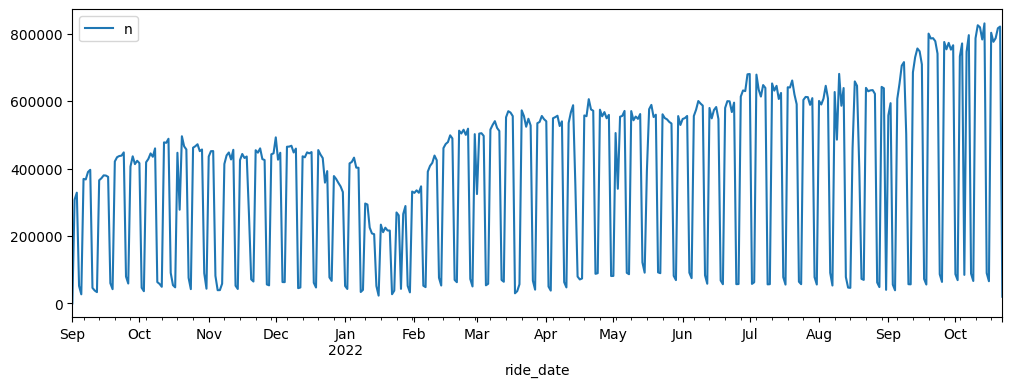

In [6]:
daily_pd = daily.to_pandas()

daily_pd.plot(x="ride_date", y="n", figsize=(12, 4))


## Coordinate Validation

In [7]:
bad_rows = 0

for p in PARQUETS:
    n = (
        pl.scan_parquet(p)
        .filter(
            (~pl.col("lat").is_between(18.8894, 19.3274))
            | (~pl.col("lng").is_between(72.7692, 73.1165))
        )
        .select(pl.len())
        .collect()
        .item()
    )

    bad_rows += n

print("Outside bbox rows:", bad_rows)


Outside bbox rows: 0


## Speed Statistics

In [3]:
(
    pl.scan_parquet([str(p) for p in PARQUETS])
    .select(
        pl.len().alias("rows"),
        pl.col("speed").mean().alias("mean_speed"),
        pl.col("speed").median().alias("median_speed"),
        pl.col("speed").max().alias("max_speed"),
        pl.col("speed").null_count().alias("null_speed"),
    )
    .collect()
)


rows,mean_speed,median_speed,max_speed,null_speed
u32,f64,f64,f64,u32
157430271,10.041118,3.9,120.0,31652283


In [4]:
(
    pl.scan_parquet([str(p) for p in PARQUETS])
    .select(
        pl.col("speed").quantile(0.50).alias("p50"),
    )
    .collect(engine="streaming")
)


p50
f64
3.9


In [5]:
(
    pl.scan_parquet([str(p) for p in PARQUETS])
    .select(pl.col("speed").quantile(0.75).alias("p75"))
    .collect(engine="streaming")
)


p75
f64
10.833


In [6]:
(
    pl.scan_parquet([str(p) for p in PARQUETS])
    .select(pl.col("speed").quantile(0.90).alias("p90"))
    .collect(engine="streaming")
)


p90
f64
21.967


In [7]:
(
    pl.scan_parquet([str(p) for p in PARQUETS])
    .select(pl.col("speed").quantile(0.95).alias("p95"))
    .collect(engine="streaming")
)


p95
f64
37.669


In [10]:
import polars as pl
from pathlib import Path

for f in sorted(Path("../data/processed").glob("*bucket0.parquet")):
    df = pl.scan_parquet(f)

    rows = df.select(pl.len()).collect().item()
    vehicles = df.select(pl.col("vehicle_id").n_unique()).collect().item()

    print(f"{f.name:70s} rows={rows:,} vehicles={vehicles:,}")


before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket0.parquet     rows=6,761,919 vehicles=20
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2_bucket0.parquet rows=6,023,350 vehicles=25
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3_bucket0.parquet rows=5,392,234 vehicles=27


In [21]:
import polars as pl
from pathlib import Path

for f in sorted(Path("../data/processed").glob("*bucket0.parquet")):
    bad = (
        pl.scan_parquet(f)
        .filter((pl.col("vehicle_id") % 8) != 0)
        .select(pl.len())
        .collect()
        .item()
    )

    print(f.name, "bad rows =", bad)


before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket0.parquet bad rows = 0
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part2_bucket0.parquet bad rows = 0
before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_part3_bucket0.parquet bad rows = 0


In [18]:
import polars as pl

df = pl.scan_parquet(
    "../data/processed/before_2022-10-22_698096e5f4994518a37a0b9c59bb9756_bucket0.parquet"
)

print(df.collect_schema())


Schema({'id': Int64, 'lat': Float64, 'lng': Float64, 'vehicle_id': Int64, 'timestamp': String, 'speed': Float64, 'source': Int32, 'deviation_s': Float64, 'ts_utc': Datetime(time_unit='us', time_zone='UTC'), 'timestamp_ist': Datetime(time_unit='us', time_zone='Asia/Kolkata'), 'ride_date': Date, 'year': Int16, 'month': Int8, 'hour': Int8})


# Findings

### Filtering Summary

- Raw GPS observations: 165.0 million
- Filtered observations: 157.4 million
- Retention: 95.4%
- Removed: 7.6 million observations

### Vehicle Coverage

- Raw vehicles observed: 250
- Vehicles retained: 246

### Spatial Coverage

- All retained observations fall within Mumbai study area
- No out-of-bounds coordinates remain

### Temporal Coverage

- Coverage spans September 2021 to October 2022
- No major temporal gaps observed

### Data Quality Status

The filtered GPS dataset satisfies timestamp validity,
spatial validity, temporal consistency, and study-area
constraints and is suitable for final deduplication and
GPS jump filtering.

### Speed Distribution

The retained speed distribution is heavily right-skewed and consistent
with urban public transport operations.

- Median speed: 3.9 km/h
- 75th percentile: 10.8 km/h
- 90th percentile: 22.0 km/h
- 95th percentile: 37.7 km/h
- Maximum reported speed: 120 km/h

Approximately 20.1% of observations contain missing device-reported
speed values. These were retained and not imputed because trajectory
reconstruction relies on timestamped GPS coordinates rather than
hardware-reported speed.

In [5]:
import polars as pl

df = pl.scan_parquet("../data/processed/pings_clean_bucket0.parquet")

print(df.select(pl.len()).collect())
print(df.select(pl.col("vehicle_id").n_unique()).collect())
print(df.collect_schema())


shape: (1, 1)
┌──────────┐
│ len      │
│ ---      │
│ u32      │
╞══════════╡
│ 18055690 │
└──────────┘
shape: (1, 1)
┌────────────┐
│ vehicle_id │
│ ---        │
│ u32        │
╞════════════╡
│ 27         │
└────────────┘
Schema({'id': Int64, 'lat': Float64, 'lng': Float64, 'vehicle_id': Int64, 'timestamp': String, 'speed': Float64, 'source': Int32, 'deviation_s': Float64, 'timestamp_ist': Datetime(time_unit='us', time_zone='Asia/Kolkata'), 'ride_date': Date, 'year': Int16, 'month': Int8, 'hour': Int8})


In [9]:
import polars as pl
from pathlib import Path

files = sorted(Path("../data/processed").glob("pings_clean_bucket*.parquet"))

summary = []

for p in files:
    rows = pl.scan_parquet(p).select(pl.len()).collect().item()

    vehicles = (
        pl.scan_parquet(p).select(pl.col("vehicle_id").n_unique()).collect().item()
    )

    summary.append(
        {
            "bucket": p.stem,
            "rows": rows,
            "vehicles": vehicles,
        }
    )

pl.DataFrame(summary).sort("bucket")


bucket,rows,vehicles
str,i64,i64
"""pings_clean_bucket0""",18055690,27
"""pings_clean_bucket1""",20905129,30
"""pings_clean_bucket2""",17919180,29
"""pings_clean_bucket3""",19510342,32
"""pings_clean_bucket4""",20630540,31
"""pings_clean_bucket5""",17602177,31
"""pings_clean_bucket6""",17568090,29


In [10]:
# Total rows currently finished
total_rows = 0
for p in sorted(Path("../data/processed").glob("pings_clean_bucket*.parquet")):
    total_rows += pl.scan_parquet(p).select(pl.len()).collect().item()

print(f"\n Total rows currently finished: {total_rows:,}")



 Total rows currently finished: 132,191,148
